In [40]:
import string
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from nltk.corpus import stopwords

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/leeroymabena/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/leeroymabena/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/leeroymabena/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [41]:
# Web-scraping

In [42]:
# Web-scrapping data
import requests 
from bs4 import BeautifulSoup
import pandas as pd

# Generate a URL and requesting
url = "https://businesstech.co.za/news/government/784466/what-south-africas-new-climate-change-laws-mean-for-businesses/"
response = requests.get(url)

# Return paragraphs
if response.status_code == 200:
    word_soup = BeautifulSoup(response.text, 'lxml')
    
    # putting all the words in a dataframe per sentence
    word_list = []
    
    for sentence in word_soup.find_all('p'):
        word_list.append(sentence.text)
    
    word_df = pd.DataFrame(word_list, columns = ['sentence'])

In [43]:
# Topic-modelling

In [44]:
# download stopwords (first time only)
nltk.download('stopwords')

# Example documents (replace with your news articles)
documents = word_list

# Stopwords
stop_words = stopwords.words('english')

# Convert text to TF-IDF matrix
vectorizer = TfidfVectorizer(stop_words=stop_words)
X = vectorizer.fit_transform(documents)

# Train LDA model
lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

# Display topics
words = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic {topic_idx + 1}:")
    print([words[i] for i in topic.argsort()[-5:]])


Topic 1:
['gas', 'emission', 'zero', 'net', 'achieve']

Topic 2:
['billionaire', 'results', 'view', 'offences', 'act']

Topic 3:
['act', 'experts', 'legal', 'change', 'climate']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/leeroymabena/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [45]:
# Textblob
from textblob import TextBlob
import numpy as np

# Define sentiment function
def sentiment(sentence):
    text_blob = TextBlob(text)
    polarity = text_blob.sentiment.polarity
    
    # Return result
    result = np.where(polarity > 0, "Positive", np.where(polarity < 0, "Negative", "Neutral"))
    return result

<Axes: xlabel='sentiment'>

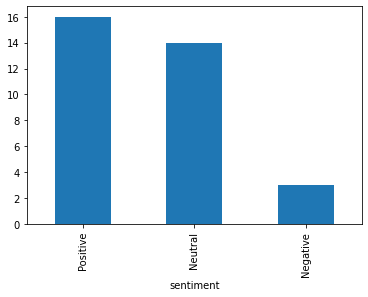

In [48]:
# Sentiment of the statements
ranking = []

for text in word_df['sentence']:
    ranking.append(sentiment(text))
    
word_df['sentiment'] = ranking

word_df['sentiment'].value_counts().plot(kind = 'bar')